# XGBoost — Strategy B: Scale Pos Weight

This notebook trains and evaluates an XGBoost classifier using Strategy B for class imbalance handling. In this strategy, the original training distribution is preserved and class imbalance is handled using `scale_pos_weight`, calculated from the ratio between non-diabetic and diabetic participants in the training set.

The model is trained on the preprocessed training set and evaluated on the original untouched test set. The results are saved for later comparison with the SMOTE-based XGBoost model and the other machine learning models.

In [15]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [16]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [17]:
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 4.296664120193532


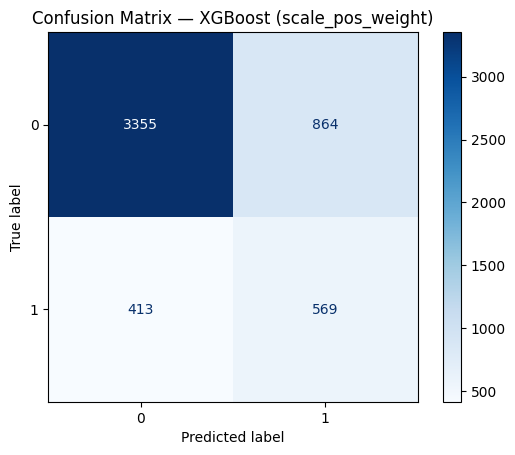

Confusion Matrix:
[[3355  864]
 [ 413  569]]
Accuracy: 0.7545
ROC AUC: 0.7801

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.80      0.84      4219
         1.0       0.40      0.58      0.47       982

    accuracy                           0.75      5201
   macro avg       0.64      0.69      0.66      5201
weighted avg       0.80      0.75      0.77      5201



In [18]:
model = XGBClassifier(n_estimators=100, objective='binary:logistic', random_state=42, scale_pos_weight=scale_pos_weight)
model.fit(X_train_final, y_train)

predictions = model.predict(X_test_final)
pred_probabilities = model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost (scale_pos_weight)")
plt.show()

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))